In [21]:
import sklearn
from sklearn.datasets import make_circles
import torch 
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn

In [22]:
n_samples=1000
X,y=make_circles(n_samples,noise=0.05,random_state=42)
len(X),len(y)

(1000, 1000)

In [23]:
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})
circles.head(10)

,X1,X2,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0
5,-0.469885,0.708037,1
6,-0.016045,0.805623,1
7,0.759623,0.159526,1
8,-0.175692,-0.799837,1
9,-0.110616,1.042207,0


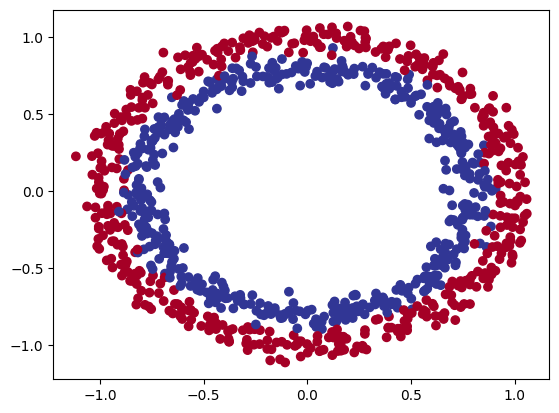

In [24]:
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [25]:
X[:5],y[:5]

(array([[ 0.74220688,  0.24668576],
        [-0.7340323 ,  0.16869164],
        [-0.82985872,  0.22195899],
        [-0.42913559,  0.67223019],
        [ 0.44560223, -0.89493556]]),
 array([1, 1, 1, 1, 0]))

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,
                                              y,test_size=0.2,random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [27]:
len(X_test)

200

In [28]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        # self.layer_1=nn.Linear(in_features=2,out_features=5)
        # self.layer_2=nn.Linear(in_features=5,out_features=1)
        self.two_linear_layer=nn.Sequential(  # direct sequential implementation
            nn.Linear(in_features=2,out_features=12),
            nn.ReLU(),       
            nn.Linear(in_features=12,out_features=1)
        )
    def forward(self,x):
        # return self.layer_2(self.layer_1(x))
        return self.two_linear_layer(x)
model=CircleModel()
model

CircleModel(
  (two_linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=1, bias=True)
  )
)

In [29]:
# model=nn.Sequential(
#     nn.Linear(in_features=2,out_features=5),
#     nn.Linear(in_features=5,out_features=1)
# )
# model

In [30]:
model.state_dict()

OrderedDict([('two_linear_layer.0.weight',
              tensor([[ 0.6488, -0.2298],
                      [-0.4370, -0.2437],
                      [-0.5180,  0.3803],
                      [-0.2281,  0.4203],
                      [ 0.0165,  0.4079],
                      [ 0.5445, -0.0239],
                      [ 0.0783, -0.6286],
                      [ 0.1953,  0.4300],
                      [ 0.5471,  0.3868],
                      [-0.3159,  0.0246],
                      [ 0.2036,  0.0213],
                      [ 0.0942, -0.0589]])),
             ('two_linear_layer.0.bias',
              tensor([-0.5330,  0.5302,  0.5214, -0.4149, -0.0680, -0.6519, -0.6147, -0.1302,
                      -0.3589,  0.5486, -0.5605, -0.1153])),
             ('two_linear_layer.2.weight',
              tensor([[-0.2855,  0.0845,  0.2629,  0.1073,  0.1857,  0.1874,  0.1410, -0.2407,
                       -0.0181,  0.0805,  0.2562,  0.0812]])),
             ('two_linear_layer.2.bias', tensor([-0.2

In [39]:
#calculating accuracy
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

In [32]:
model.eval()
with torch.inference_mode():
    y_logits=model(X_test)[:5]
y_logits #now the value we got here are raw values after values are passed thru forward pass

tensor([[ 0.1279],
        [ 0.0390],
        [ 0.0966],
        [ 0.1240],
        [-0.1555]])

In [33]:
y_probs=torch.sigmoid(y_logits)
y_probs # as the above values are raw and we cant predict or do anything we need activation function so values pas thru them 
#and we can check if its class 1 or not by rounding of basically sigmoid convert it between 0 and 1

tensor([[0.5319],
        [0.5097],
        [0.5241],
        [0.5309],
        [0.4612]])

In [34]:
y_preds=torch.round(y_probs)
y_preds # so now in this cell if values of probs>=0.5 it will be classified as 1 else 0 

# so basically idea is pass thru forward pass get raw input values converted then pass thru acitvation function then round off
# and get final output

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [0.]])

In [35]:
loss_fn=torch.nn.BCEWithLogitsLoss() # combine sigmoid layer and BCE layer together
optimizer=torch.optim.Adam(params=model.parameters(),lr=0.01)


In [40]:
# the current code is for direct measuring and calculating losses while manual passing of sigmoid and rounding off is basically used for
#iterating and doing same stuff manually and commented one uses BCEWtih logits which has built in sigmoid
epochs=200
train_loss_values = []
test_loss_values = []
epoch_count = []
for epoch in range(epochs):
    model.train()
    y_logits=model(X_train)
    # y_pred_train=model(X_train)
    y_pred_train=torch.round(torch.sigmoid(y_logits))
    # loss=loss_fn(y_pred_train,y_train)
    loss=loss_fn(y_logits,y_train) # here we are using logits instead of y_pred_train becoz logits is the raw value we got from forward pass
    # while if we pass y_pred_train it has round off values 0&1 which will not allow us to manupilate the gradientsn properly nor we can 
    #loss of pred and actual values
    acc=accuracy_fn(y_true=y_train,y_pred=y_pred_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.inference_mode():
        y_test_pred=model(X_test)
        y_test_loss=loss_fn(y_test_pred,y_test)
    
    if epoch%10==0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(y_test_loss.detach().numpy())
        print(model.state_dict())
        print(f"Train loss {loss}")
        print(f"Test Loss {y_test_loss}")
        print(epoch)


OrderedDict([('two_linear_layer.0.weight', tensor([[ 0.6588, -0.2398],
        [-0.4270, -0.2537],
        [-0.5080,  0.3703],
        [-0.2181,  0.4103],
        [ 0.0265,  0.3979],
        [ 0.5445, -0.0239],
        [ 0.0683, -0.6186],
        [ 0.1853,  0.4400],
        [ 0.5571,  0.3968],
        [-0.3059,  0.0146],
        [ 0.2036,  0.0213],
        [ 0.0842, -0.0489]])), ('two_linear_layer.0.bias', tensor([-0.5230,  0.5402,  0.5314, -0.4249, -0.0780, -0.6519, -0.6247, -0.1402,
        -0.3489,  0.5586, -0.5605, -0.1253])), ('two_linear_layer.2.weight', tensor([[-0.2955,  0.0745,  0.2529,  0.0973,  0.1757,  0.1874,  0.1310, -0.2507,
         -0.0281,  0.0705,  0.2562,  0.0712]])), ('two_linear_layer.2.bias', tensor([-0.2309]))])
Train loss 0.6950819492340088
Test Loss 0.6937291026115417
0
OrderedDict([('two_linear_layer.0.weight', tensor([[ 0.7539, -0.3352],
        [-0.3424, -0.3016],
        [-0.4189,  0.2939],
        [-0.1546,  0.3467],
        [ 0.0791,  0.3047],
        [ 

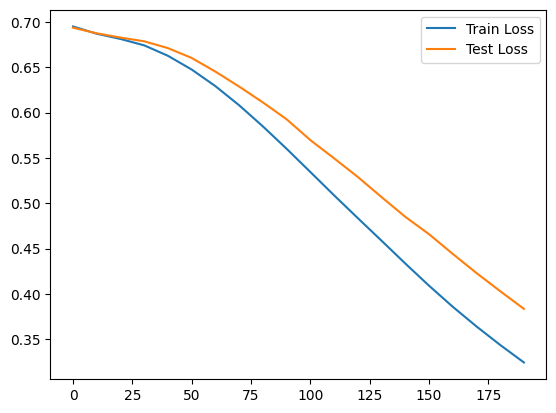

In [41]:
import matplotlib.pyplot as plt

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# create a grid
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# convert grid to tensor
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# model predictions
model.eval()
with torch.inference_mode():
    logits = model(grid_tensor)
    probs = torch.sigmoid(logits)
    preds = torch.round(probs)

Z = preds.reshape(xx.shape)

# plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Decision Boundary")
plt.show()